# Graph Representations for Molecule Analysis

This notebook turns the abstract graph-theory requirements into concrete graph representations built from the available molecular datasets.

Representations in this notebook:
- a toy atom-bond graph
- a molecule-assay bipartite graph from Tox21
- a molecule-similarity graph from BBBP SMILES strings

In [90]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

In [91]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))
bbbp = pd.read_csv(DATA_DIR / "BBBP.csv")
tox21 = pd.read_csv(DATA_DIR / "tox21.csv")
print("BBBP shape:", bbbp.shape)
print("Tox21 shape:", tox21.shape)

BBBP shape: (2050, 4)
Tox21 shape: (7831, 14)


## 3. Molecule-Similarity Graph from BBBP SMILES

Without RDKit, we can still build a useful graph by connecting molecules whose character n-gram profiles are similar.

In [ ]:
similarity_sample = bbbp[["name", "smiles", "p_np"]].head(20).copy()
vectorizer = CountVectorizer(analyzer="char", ngram_range=(2, 4), min_df=1)
feature_matrix = vectorizer.fit_transform(similarity_sample["smiles"])
similarity = cosine_similarity(feature_matrix)
similarity_graph = (similarity >= 0.45).astype(int)
np.fill_diagonal(similarity_graph, 0)
degree_df = pd.DataFrame(
    {
        "molecule": similarity_sample["name"].fillna(
            similarity_sample.index.to_series().astype(str)
        ),
        "degree": similarity_graph.sum(axis=1),
        "target": similarity_sample["p_np"],
    }
)
display(degree_df.head(10))

,molecule,degree,target
0,Propanolol,13,1
1,Terbutylchlorambucil,14,1
2,40730,7,1
3,24,10,1
4,cloxacillin,13,1
5,cefoperazone,9,1
6,rolitetracycline,6,1
7,ondansetron,13,1
8,diltiazem,15,1
9,Amiloride,1,1


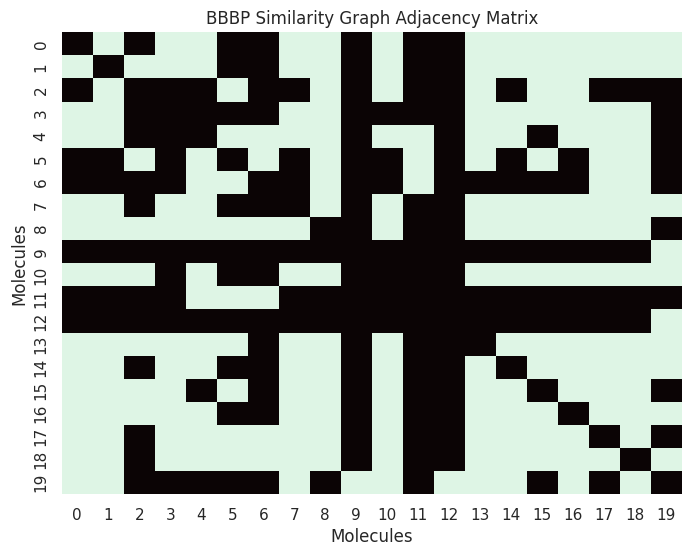

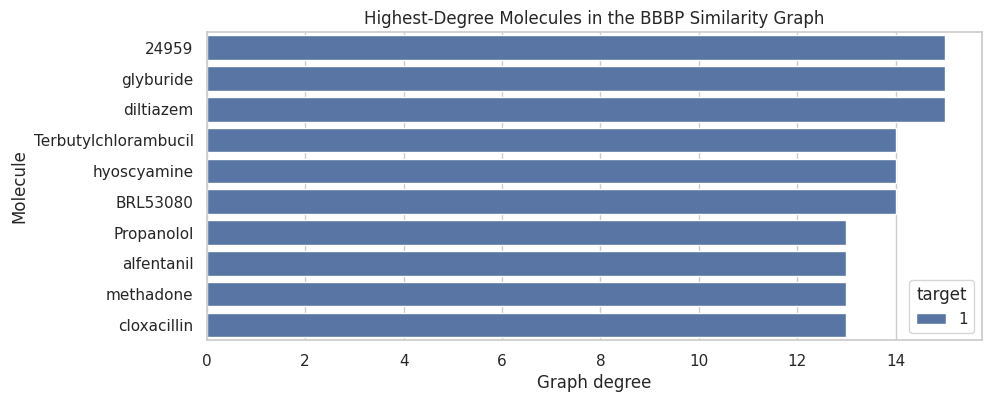

In [102]:
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_graph, cmap="mako", cbar=False)
plt.title("BBBP Similarity Graph Adjacency Matrix")
plt.xlabel("Molecules")
plt.ylabel("Molecules")
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(
    data=degree_df.sort_values("degree", ascending=False).head(10),
    x="degree",
    y="molecule",
    hue="target",
)
plt.title("Highest-Degree Molecules in the BBBP Similarity Graph")
plt.xlabel("Graph degree")
plt.ylabel("Molecule")
plt.show()

## Why These Graph Views Matter

These three representations map directly onto later modeling work:
- atom-bond graphs lead to message passing and GNNs
- molecule-assay bipartite graphs lead to link prediction and multitask structure
- similarity graphs lead to neighborhood methods and graph regularization